🎯 Accuracy Score: 99.74%

📋 Detailed Classification Report:
                  precision    recall  f1-score   support

          Casein       1.00      1.00      1.00       612
   Plant_Protein       1.00      1.00      1.00       277
Whey_Concentrate       0.99      1.00      1.00       275
    Whey_Isolate       1.00      0.62      0.77         8

        accuracy                           1.00      1172
       macro avg       1.00      0.91      0.94      1172
    weighted avg       1.00      1.00      1.00      1172



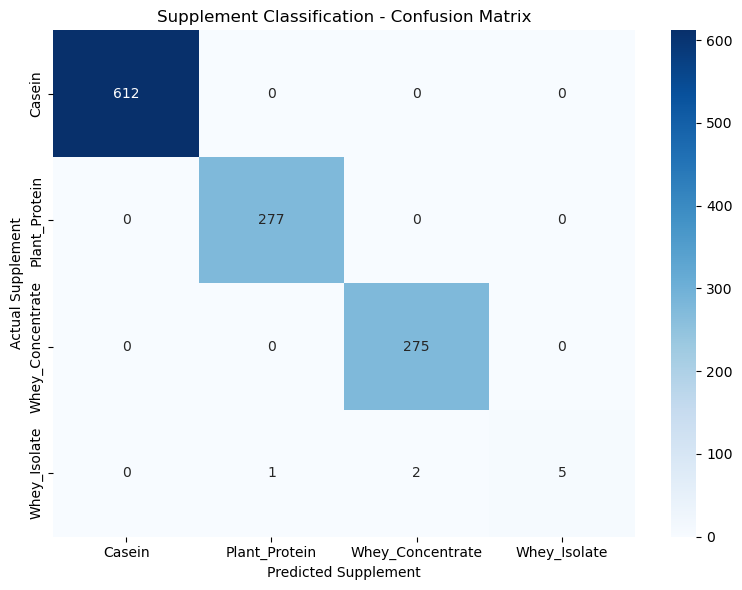

💾 مدل طبقه‌بندی مکمل با موفقیت ذخیره شد!


In [1]:
# سلول اول: وارد کردن کتابخانه‌های مورد نیاز
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import os

# سلول دوم: بارگذاری دیتاسِت مهندسی‌شده جدید از مسیر پردازش‌شده
data_path = r"C:\Windows\System32\protein-recommendation-ai\protein-recommendation-ai\data\processed\NHANES_Processed_With_Supplements.csv"
df = pd.read_csv(data_path)

# تبدیل جنسیت به مقدار عددی
df['Gender_Encoded'] = df['Gender'].map({'Female': 0, 'Male': 1})

# سلول سوم: تعریف ویژگی‌ها (X) و هدف جدید (y)
features = ['Age', 'Gender_Encoded', 'Weight_kg', 'Height_cm', 'BMI', 'Body_Fat_Percent', 'Lean_Mass_kg', 'Activity_Score', 'Genetic_Score']
X = df[features]
y = df['Recommended_Supplement_Type']

# تقسیم داده‌ها به دو بخش آموزش و تست (80% آموزش، 20% تست)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# سلول چهارم: آموزش مدل دسته‌بندی کننده Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# پیش‌بینی روی داده‌های تست
y_pred = clf.predict(X_test)

# سلول پنجم: ارزیابی دقیق مدل و چاپ گزارش عملکرد
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Accuracy Score: {accuracy * 100:.2f}%\n")
print("📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# سلول ششم: رسم و ذخیره ماتریس آشفتگی (Confusion Matrix)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title('Supplement Classification - Confusion Matrix')
plt.ylabel('Actual Supplement')
plt.xlabel('Predicted Supplement')
plt.tight_layout()

# ذخیره اتوماتیک نمودار در پوشه figures
figures_dir = r"C:\Windows\System32\protein-recommendation-ai\protein-recommendation-ai\reports\figures"
plt.savefig(os.path.join(figures_dir, '06_supplement_confusion_matrix.png'), dpi=300)
plt.show()

# سلول هفتم: ذخیره مدل آموزش‌دیده برای استفاده در Agent (فازهای بعدی)
models_dir = r"C:\Windows\System32\protein-recommendation-ai\protein-recommendation-ai\models"
joblib.dump(clf, os.path.join(models_dir, 'trained_supplement_classifier.pkl'))
print("💾 مدل طبقه‌بندی مکمل با موفقیت ذخیره شد!")